In [1]:
import os
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sklearn.metrics import jaccard_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms

In [2]:
@dataclass
class Config:
    image_size = (128, 128)
    batch_size = 32
    epochs = 15
    learning_rate = 0.0001
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_split = 0.8

config = Config()

In [3]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        self.enc1 = self.conv_block(in_channels, 64)
        self.enc2 = self.conv_block(64, 128)
        self.enc3 = self.conv_block(128, 256)
        self.enc4 = self.conv_block(256, 512)

        self.bottleneck = self.conv_block(512, 1024)

        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = self.conv_block(1024, 512)

        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = self.conv_block(512, 256)

        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = self.conv_block(256, 128)

        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = self.conv_block(128, 64)

        self.out = nn.Conv2d(64, out_channels, kernel_size=1)

        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool(enc1))
        enc3 = self.enc3(self.pool(enc2))
        enc4 = self.enc4(self.pool(enc3))

        bottleneck = self.bottleneck(self.pool(enc4))

        dec4 = self.upconv4(bottleneck)
        dec4 = torch.cat([dec4, enc4], dim=1)
        dec4 = self.dec4(dec4)

        dec3 = self.upconv3(dec4)
        dec3 = torch.cat([dec3, enc3], dim=1)
        dec3 = self.dec3(dec3)

        dec2 = self.upconv2(dec3)
        dec2 = torch.cat([dec2, enc2], dim=1)
        dec2 = self.dec2(dec2)

        dec1 = self.upconv1(dec2)
        dec1 = torch.cat([dec1, enc1], dim=1)
        dec1 = self.dec1(dec1)

        out = self.out(dec1)

        return out

    def conv_block(self, in_channels, out_channels):
        res_block = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
        )

        return res_block


In [4]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None):
        self.root = root
        self.transform = transform
        self.dataset = torchvision.datasets.OxfordIIITPet(root=root, split=split, target_types='segmentation', download=True)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize((128, 128))
        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [5]:
class Trainer:
    def __init__(self, config):
        self.config = config

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

        self.model = UNet().to(config.device)
        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.learning_rate)

        self.test_loss = None
        self.test_iou = None
        self.test_f1 = None

        self.setup_dataloader()

        self.train_losses = []
        self.val_losses = []
        self.val_ious = []

    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split='trainval', transform=self.transform)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        self.test_dataset = PetDataset(root="./data", split='test', transform=self.transform)

        self.train_dataloader = DataLoader(train_dataset, batch_size=self.config.batch_size, shuffle=True)
        self.val_dataloader = DataLoader(val_dataset, batch_size=self.config.batch_size, shuffle=False)
        self.test_dataloader = DataLoader(self.test_dataset, batch_size=self.config.batch_size, shuffle=False)

    def run(self):
        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()

            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.val_ious.append(val_iou)

            print(f"Epoch {epoch+1} / {self.config.epochs}, "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val IoU: {val_iou:.4f}, "
                  f"Val F1-score: {val_f1:.4f}")

        self.plot_training()

        test_loss, test_iou, test_f1 = self.test()

        self.test_loss = test_loss
        self.test_iou = test_iou
        self.test_f1 = test_f1

        print(f"Test Loss: {test_loss:.4f}, "
              f"Test IoU: {test_iou:.4f}, "
              f"Test F1-score: {test_f1:.4f}")

    def train(self):
        self.model.train()
        epoch_loss = 0

        for images, masks in tqdm(self.train_dataloader):
            images = images.to(self.config.device)
            masks = masks.to(self.config.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)

            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)

    def validate(self):
        self.model.eval()
        val_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                val_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return val_loss / len(self.val_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def test(self):
        self.model.eval()
        test_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                test_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return test_loss / len(self.test_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()

        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))

            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)

                output = self.model(img_tensor)
                output = torch.sigmoid(output).squeeze().cpu().numpy()
                output = (output >= 0.5).astype('float')

                axes[i, 0].imshow(img.permute(1, 2, 0).cpu())
                axes[i, 0].set_title("Image")
                axes[i, 1].imshow(mask.squeeze().cpu(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 2].imshow(output, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")

            plt.show()

    def plot_training(self):
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.plot(self.train_losses, label='Train Loss')
        plt.plot(self.val_losses, label='Val Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.title('Loss Curves')

        plt.subplot(1, 2, 2)
        plt.plot(self.val_ious, label='Val IoU', color='green')
        plt.xlabel('Epoch')
        plt.ylabel('IoU')
        plt.legend()
        plt.title('IoU Curve')

        plt.tight_layout()

        plt.show()


100%|██████████| 23/23 [00:11<00:00,  1.92it/s]


Epoch 1 / 15, Train Loss: 0.6205, Val Loss: 0.5593, Val IoU: 0.5126, Val F1-score: 0.6750


100%|██████████| 23/23 [00:11<00:00,  1.94it/s]


Epoch 2 / 15, Train Loss: 0.4744, Val Loss: 0.4344, Val IoU: 0.7609, Val F1-score: 0.8566


100%|██████████| 23/23 [00:12<00:00,  1.87it/s]


...

Epoch 13 / 15, Train Loss: 0.2753, Val Loss: 0.2760, Val IoU: 0.8420, Val F1-score: 0.9088


100%|██████████| 23/23 [00:12<00:00,  1.91it/s]


Epoch 14 / 15, Train Loss: 0.2615, Val Loss: 0.2665, Val IoU: 0.8392, Val F1-score: 0.9074


100%|██████████| 23/23 [00:12<00:00,  1.91it/s]


Epoch 15 / 15, Train Loss: 0.2439, Val Loss: 0.2509, Val IoU: 0.8570, Val F1-score: 0.9178


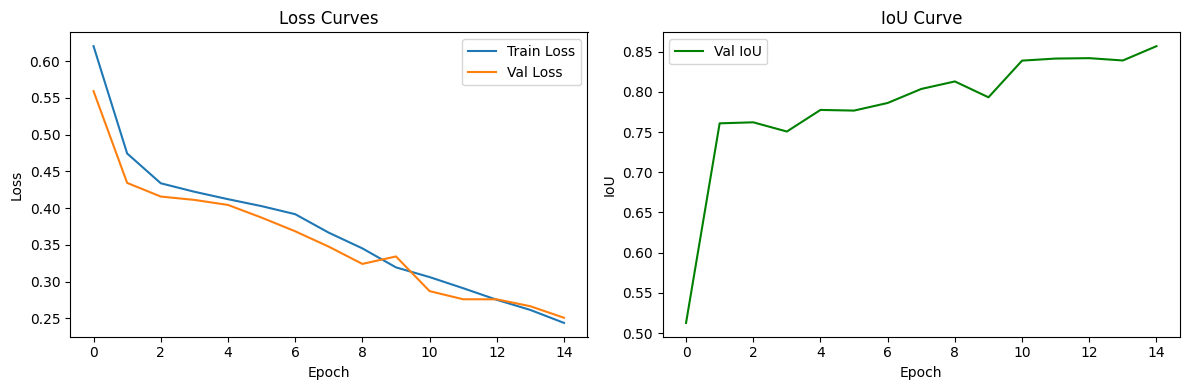

100%|██████████| 115/115 [01:01<00:00,  1.88it/s]


Test Loss: 0.2604, Test IoU: 0.8509, Test F1-score: 0.9137


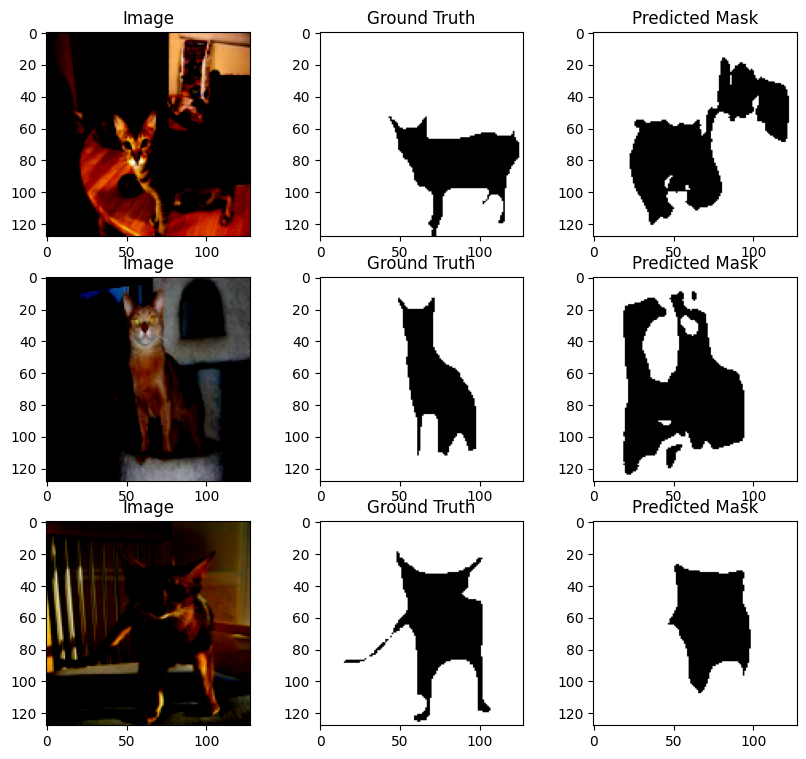

In [ ]:
trainer = Trainer(config)
trainer.run()

trainer.inference_and_plot_samples(n_samples=3)

#Перебор гиперпараметров

In [ ]:
lrs = [0.001, 0.0001, 0.00001]
bss = [16, 8]


lr=0.001, bs=16


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 46/46 [00:14<00:00,  3.08it/s]


Epoch 1 / 6, Train Loss: 0.6040, Val Loss: 0.4756, Val IoU: 0.7314, Val F1-score: 0.8352


100%|██████████| 46/46 [00:16<00:00,  2.85it/s]


Epoch 2 / 6, Train Loss: 0.4509, Val Loss: 0.4591, Val IoU: 0.7364, Val F1-score: 0.8377


...

Epoch 4 / 6, Train Loss: 0.4207, Val Loss: 0.4113, Val IoU: 0.7624, Val F1-score: 0.8576


100%|██████████| 46/46 [00:12<00:00,  3.60it/s]


Epoch 5 / 6, Train Loss: 0.4098, Val Loss: 0.3985, Val IoU: 0.7706, Val F1-score: 0.8628


100%|██████████| 46/46 [00:16<00:00,  2.76it/s]


Epoch 6 / 6, Train Loss: 0.3947, Val Loss: 0.3721, Val IoU: 0.7863, Val F1-score: 0.8733


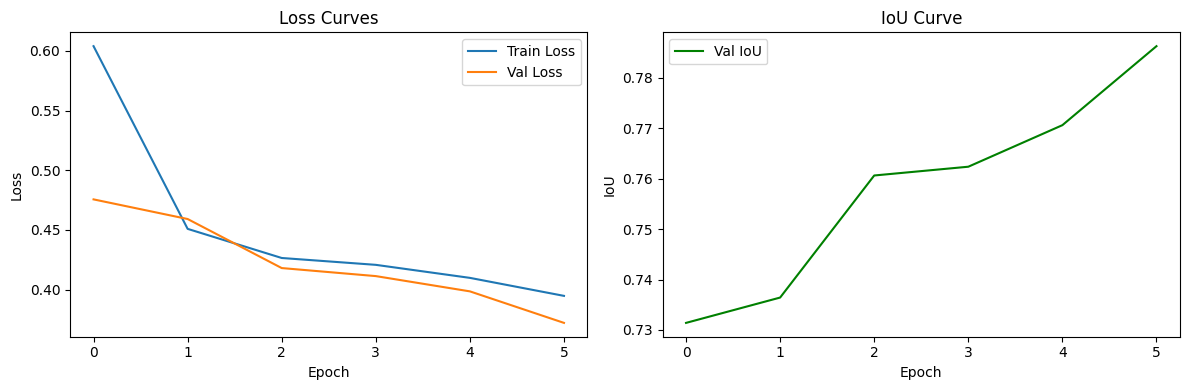

100%|██████████| 230/230 [01:13<00:00,  3.14it/s]
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Test Loss: 0.3702, Test IoU: 0.7892, Test F1-score: 0.8746

lr=0.001, bs=8


100%|██████████| 92/92 [00:17<00:00,  5.22it/s]


Epoch 1 / 6, Train Loss: 0.4882, Val Loss: 0.4547, Val IoU: 0.7516, Val F1-score: 0.8532


100%|██████████| 92/92 [00:13<00:00,  6.68it/s]


...

Epoch 4 / 6, Train Loss: 0.4187, Val Loss: 0.4090, Val IoU: 0.7718, Val F1-score: 0.8644


100%|██████████| 92/92 [00:17<00:00,  5.32it/s]


Epoch 5 / 6, Train Loss: 0.4095, Val Loss: 0.3971, Val IoU: 0.7755, Val F1-score: 0.8672


100%|██████████| 92/92 [00:13<00:00,  6.63it/s]


Epoch 6 / 6, Train Loss: 0.3842, Val Loss: 0.3521, Val IoU: 0.7976, Val F1-score: 0.8822


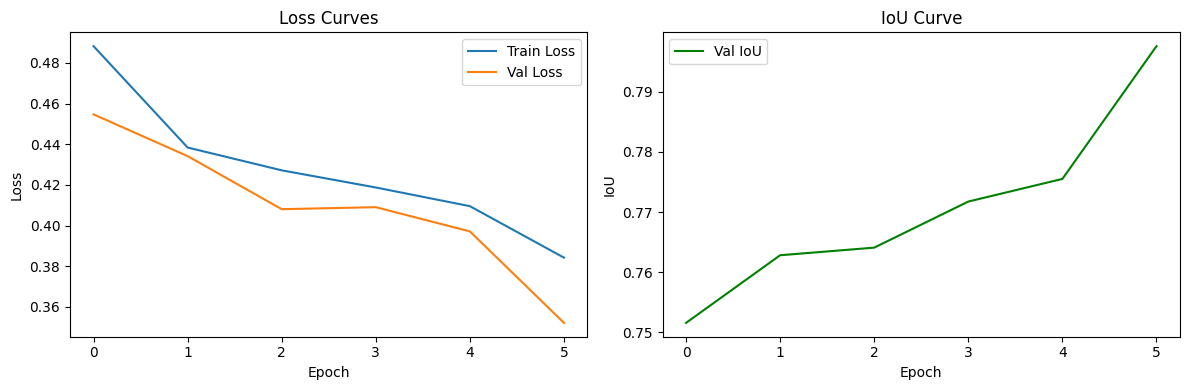

100%|██████████| 459/459 [01:21<00:00,  5.67it/s]
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Test Loss: 0.3557, Test IoU: 0.7957, Test F1-score: 0.8794

lr=0.0001, bs=16


100%|██████████| 46/46 [00:12<00:00,  3.60it/s]


Epoch 1 / 6, Train Loss: 0.5573, Val Loss: 0.4582, Val IoU: 0.7505, Val F1-score: 0.8496


100%|██████████| 46/46 [00:15<00:00,  2.89it/s]


...

Epoch 4 / 6, Train Loss: 0.4085, Val Loss: 0.4001, Val IoU: 0.7697, Val F1-score: 0.8632


100%|██████████| 46/46 [00:15<00:00,  2.91it/s]


Epoch 5 / 6, Train Loss: 0.3816, Val Loss: 0.4219, Val IoU: 0.7364, Val F1-score: 0.8424


100%|██████████| 46/46 [00:13<00:00,  3.53it/s]


Epoch 6 / 6, Train Loss: 0.3568, Val Loss: 0.3854, Val IoU: 0.7865, Val F1-score: 0.8722


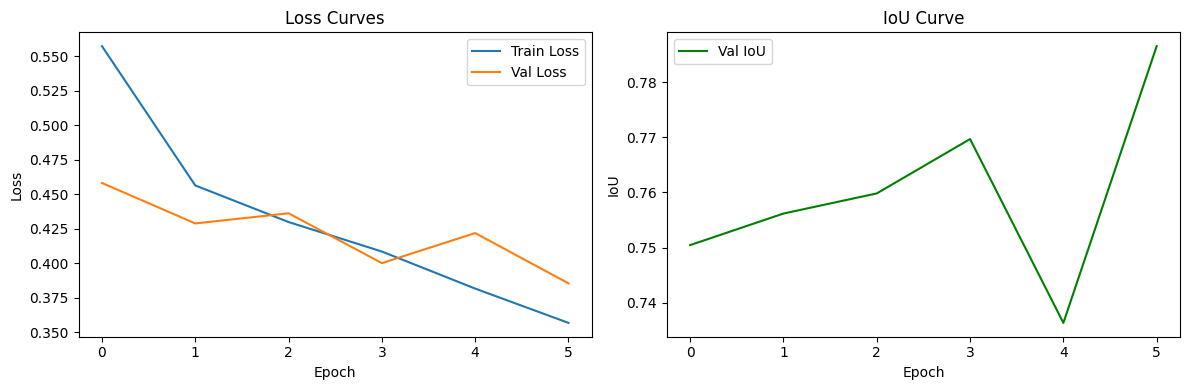

100%|██████████| 230/230 [01:05<00:00,  3.51it/s]
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Test Loss: 0.3723, Test IoU: 0.7905, Test F1-score: 0.8742

lr=0.0001, bs=8


100%|██████████| 92/92 [00:13<00:00,  6.67it/s]


Epoch 1 / 6, Train Loss: 0.4991, Val Loss: 0.4334, Val IoU: 0.7465, Val F1-score: 0.8492


100%|██████████| 92/92 [00:13<00:00,  6.76it/s]


...

Epoch 4 / 6, Train Loss: 0.3745, Val Loss: 0.3584, Val IoU: 0.7993, Val F1-score: 0.8828


100%|██████████| 92/92 [00:13<00:00,  6.82it/s]


Epoch 5 / 6, Train Loss: 0.3321, Val Loss: 0.3406, Val IoU: 0.7963, Val F1-score: 0.8818


100%|██████████| 92/92 [00:13<00:00,  6.78it/s]


Epoch 6 / 6, Train Loss: 0.2961, Val Loss: 0.2915, Val IoU: 0.8354, Val F1-score: 0.9048


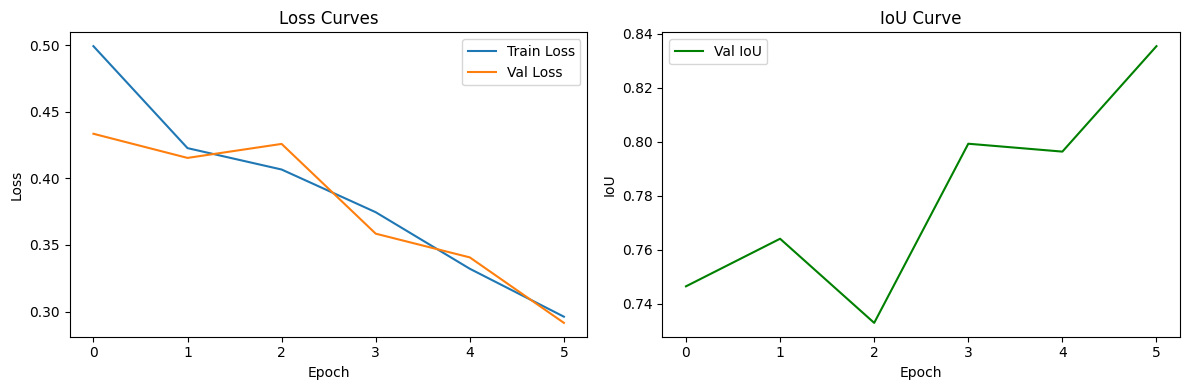

100%|██████████| 459/459 [01:09<00:00,  6.59it/s]
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Test Loss: 0.2875, Test IoU: 0.8356, Test F1-score: 0.9039

lr=1e-05, bs=16


100%|██████████| 46/46 [00:12<00:00,  3.65it/s]


Epoch 1 / 6, Train Loss: 0.6511, Val Loss: 0.5450, Val IoU: 0.6907, Val F1-score: 0.8049


100%|██████████| 46/46 [00:12<00:00,  3.58it/s]


...

Epoch 4 / 6, Train Loss: 0.4652, Val Loss: 0.4664, Val IoU: 0.7349, Val F1-score: 0.8403


100%|██████████| 46/46 [00:12<00:00,  3.62it/s]


Epoch 5 / 6, Train Loss: 0.4565, Val Loss: 0.4537, Val IoU: 0.7439, Val F1-score: 0.8453


100%|██████████| 46/46 [00:12<00:00,  3.56it/s]


Epoch 6 / 6, Train Loss: 0.4448, Val Loss: 0.4560, Val IoU: 0.7443, Val F1-score: 0.8448


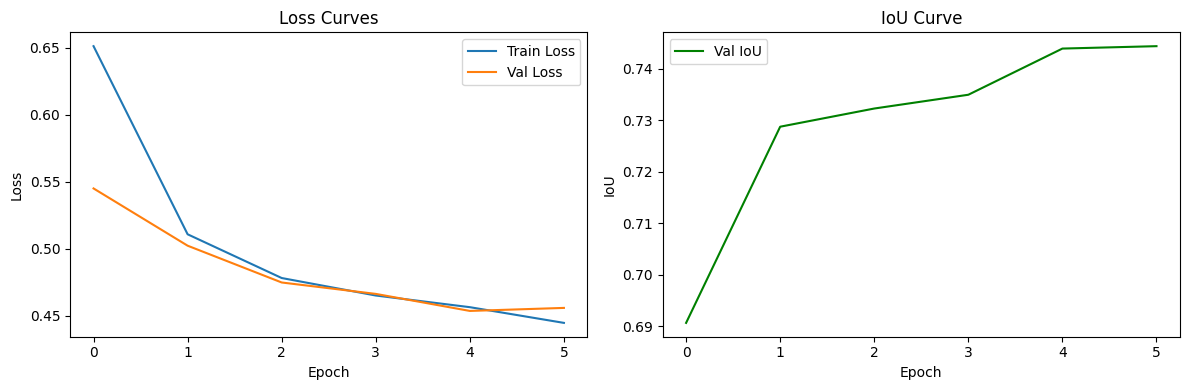

100%|██████████| 230/230 [01:20<00:00,  2.87it/s]
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Test Loss: 0.4447, Test IoU: 0.7529, Test F1-score: 0.8501

lr=1e-05, bs=8


100%|██████████| 92/92 [00:17<00:00,  5.16it/s]


Epoch 1 / 6, Train Loss: 0.5925, Val Loss: 0.4913, Val IoU: 0.7244, Val F1-score: 0.8356


100%|██████████| 92/92 [00:13<00:00,  6.76it/s]


...

Epoch 4 / 6, Train Loss: 0.4612, Val Loss: 0.4538, Val IoU: 0.7569, Val F1-score: 0.8548


100%|██████████| 92/92 [00:15<00:00,  6.03it/s]


Epoch 5 / 6, Train Loss: 0.4493, Val Loss: 0.4316, Val IoU: 0.7647, Val F1-score: 0.8598


100%|██████████| 92/92 [00:16<00:00,  5.56it/s]


Epoch 6 / 6, Train Loss: 0.4354, Val Loss: 0.4294, Val IoU: 0.7685, Val F1-score: 0.8619


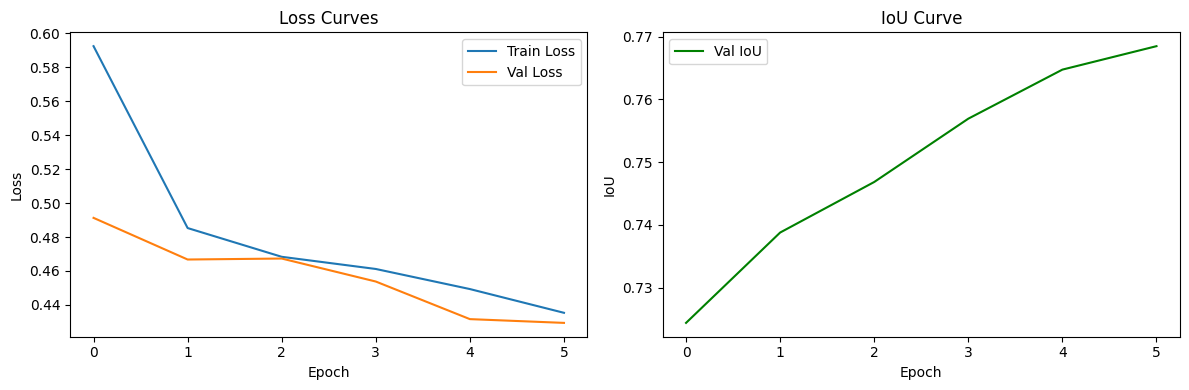

100%|██████████| 459/459 [01:10<00:00,  6.50it/s]


Test Loss: 0.4333, Test IoU: 0.7609, Test F1-score: 0.8556

Results:
lr=0.001, bs=16: IoU=0.7892, F1=0.8746
lr=0.001, bs=8: IoU=0.7957, F1=0.8794
lr=0.0001, bs=16: IoU=0.7905, F1=0.8742
lr=0.0001, bs=8: IoU=0.8356, F1=0.9039
lr=1e-05, bs=16: IoU=0.7529, F1=0.8501
lr=1e-05, bs=8: IoU=0.7609, F1=0.8556


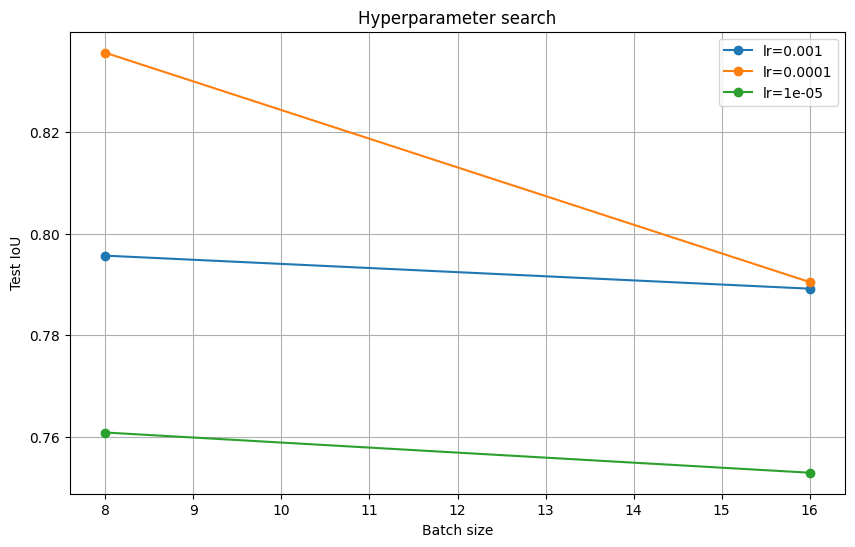

In [ ]:
results = []

for lr in lrs:
    for bs in bss:
        print(f"\nlr={lr}, bs={bs}")

        config = Config()
        config.learning_rate = lr
        config.batch_size = bs
        config.epochs = 6

        trainer = Trainer(config)
        trainer.run()

        results.append({
            'lr': lr,
            'batch_size': bs,
            'iou': trainer.test_iou,
            'f1': trainer.test_f1
        })

        del trainer
        torch.cuda.empty_cache()

print("\n" + "="*50)
print("Results:")
print("="*50)
for r in results:
    print(f"lr={r['lr']}, bs={r['batch_size']}: IoU={r['iou']:.4f}, F1={r['f1']:.4f}")

plt.figure(figsize=(10, 6))
for lr in lrs:
    lr_results = [r for r in results if r['lr'] == lr]
    bs_vals = [r['batch_size'] for r in lr_results]
    iou_vals = [r['iou'] for r in lr_results]
    plt.plot(bs_vals, iou_vals, marker='o', label=f'lr={lr}')
plt.xlabel('Batch size')
plt.ylabel('Test IoU')
plt.title('Hyperparameter search')
plt.legend()
plt.grid(True)
plt.show()

###Лучший результат при learning rate = 0.0001 и batch size = 8 (IoU = 0.8356). При lr = 0.00001 обучение происходит очень медленно, поэтому за 6 эпох хорошие метрики не достигаются, так что в этом эксперименте более оптимальным оказался lr = 0.0001.

#Модификация U-Net: BatchNorm + Dropout

In [8]:
class UNetModified(UNet):
    def __init__(self, in_channels=3, out_channels=1, dropout_rate=0.3):
        self.dropout_rate = dropout_rate
        super().__init__(in_channels, out_channels)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(self.dropout_rate),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(self.dropout_rate),
        )

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 792M/792M [00:39<00:00, 20.0MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 12.6MB/s]
100%|██████████| 92/92 [00:13<00:00,  6.62it/s]


Epoch 1 / 10, Train Loss: 0.5323, Val Loss: 0.4472, Val IoU: 0.7306, Val F1-score: 0.8391


100%|██████████| 92/92 [00:12<00:00,  7.13it/s]


Epoch 2 / 10, Train Loss: 0.4373, Val Loss: 0.4290, Val IoU: 0.7402, Val F1-score: 0.8453


100%|██████████| 92/92 [00:12<00:00,  7.19it/s]


...

Epoch 8 / 10, Train Loss: 0.2818, Val Loss: 0.2669, Val IoU: 0.8396, Val F1-score: 0.9075


100%|██████████| 92/92 [00:13<00:00,  7.05it/s]


Epoch 9 / 10, Train Loss: 0.2570, Val Loss: 0.2530, Val IoU: 0.8537, Val F1-score: 0.9163


100%|██████████| 92/92 [00:12<00:00,  7.12it/s]


Epoch 10 / 10, Train Loss: 0.2366, Val Loss: 0.2451, Val IoU: 0.8620, Val F1-score: 0.9208


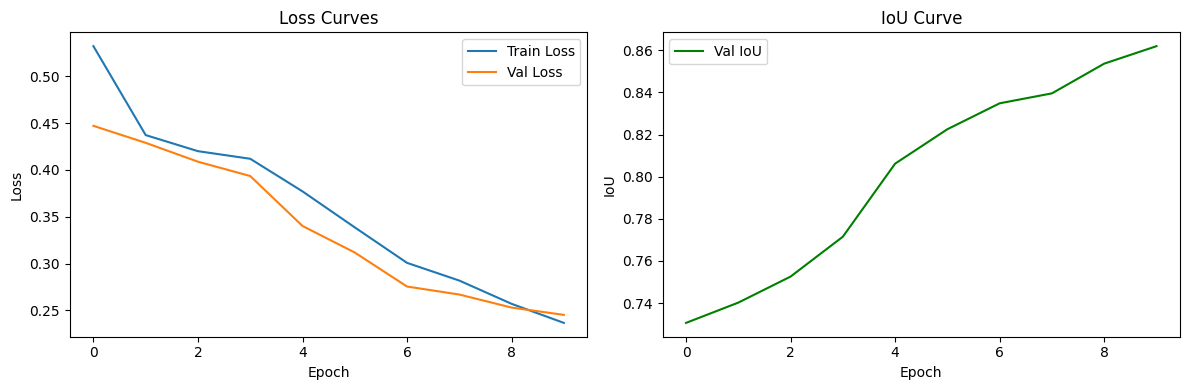

100%|██████████| 459/459 [01:05<00:00,  6.99it/s]

Test Loss: 0.2395, Test IoU: 0.8611, Test F1-score: 0.9200

Baseline results:
IoU: 0.8611
F1: 0.9200


In [7]:
config = Config()
config.learning_rate = 0.0001
config.batch_size = 8
config.epochs = 10

trainer = Trainer(config)
trainer.run()

base_iou = trainer.test_iou
base_f1 = trainer.test_f1
base_train_losses = trainer.train_losses
base_val_losses = trainer.val_losses
base_val_ious = trainer.val_ious

print(f"\nBaseline results:")
print(f"IoU: {base_iou:.4f}")
print(f"F1: {base_f1:.4f}")

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 92/92 [00:12<00:00,  7.19it/s]


Epoch 1 / 10, Train Loss: 0.5463, Val Loss: 0.4448, Val IoU: 0.7487, Val F1-score: 0.8500


100%|██████████| 92/92 [00:12<00:00,  7.19it/s]


Epoch 2 / 10, Train Loss: 0.4490, Val Loss: 0.4320, Val IoU: 0.7593, Val F1-score: 0.8556


100%|██████████| 92/92 [00:12<00:00,  7.16it/s]


...

Epoch 8 / 10, Train Loss: 0.3281, Val Loss: 0.2960, Val IoU: 0.8197, Val F1-score: 0.8959


100%|██████████| 92/92 [00:12<00:00,  7.31it/s]


Epoch 9 / 10, Train Loss: 0.3146, Val Loss: 0.2883, Val IoU: 0.8316, Val F1-score: 0.9029


100%|██████████| 92/92 [00:12<00:00,  7.33it/s]


Epoch 10 / 10, Train Loss: 0.3056, Val Loss: 0.2597, Val IoU: 0.8464, Val F1-score: 0.9121


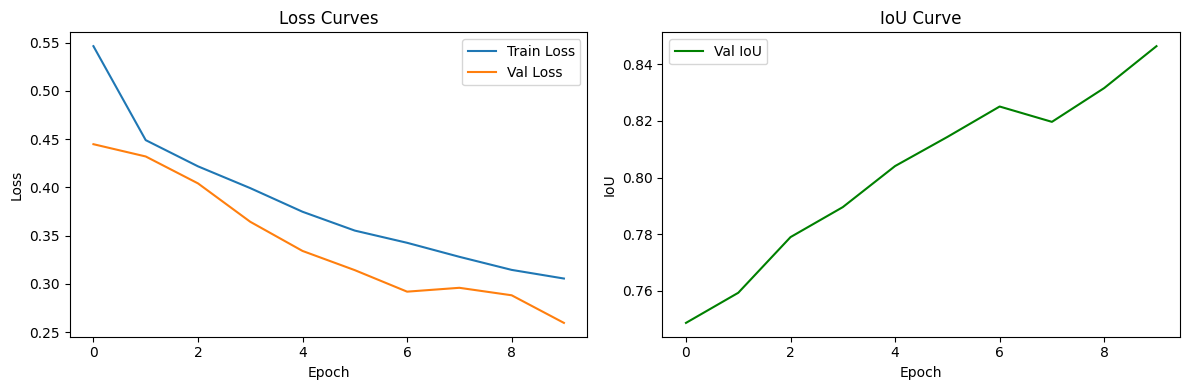

100%|██████████| 459/459 [01:05<00:00,  6.98it/s]

Test Loss: 0.2550, Test IoU: 0.8480, Test F1-score: 0.9125

Modified results:
IoU: 0.8480
F1: 0.9125


In [9]:
config = Config()
config.learning_rate = 0.0001
config.batch_size = 8
config.epochs = 10

trainer_modified = Trainer(config)
trainer_modified.model = UNetModified(dropout_rate=0.3).to(config.device)
trainer_modified.optimizer = optim.Adam(trainer_modified.model.parameters(), lr=config.learning_rate)

trainer_modified.run()

modified_iou = trainer_modified.test_iou
modified_f1 = trainer_modified.test_f1
modified_train_losses = trainer_modified.train_losses
modified_val_losses = trainer_modified.val_losses
modified_val_ious = trainer_modified.val_ious

print(f"\nModified results:")
print(f"IoU: {modified_iou:.4f}")
print(f"F1: {modified_f1:.4f}")

#Сравнение моделей

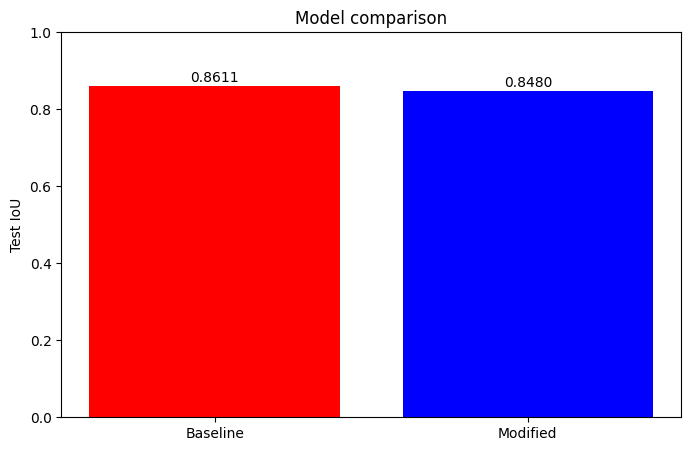

In [10]:
plt.figure(figsize=(8, 5))
models = ['Baseline', 'Modified']
ious = [base_iou, modified_iou]
bars = plt.bar(models, ious, color=['red', 'blue'])
plt.ylabel('Test IoU')
plt.title('Model comparison')
plt.ylim(0, 1)
for bar, val in zip(bars, ious):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center')
plt.show()

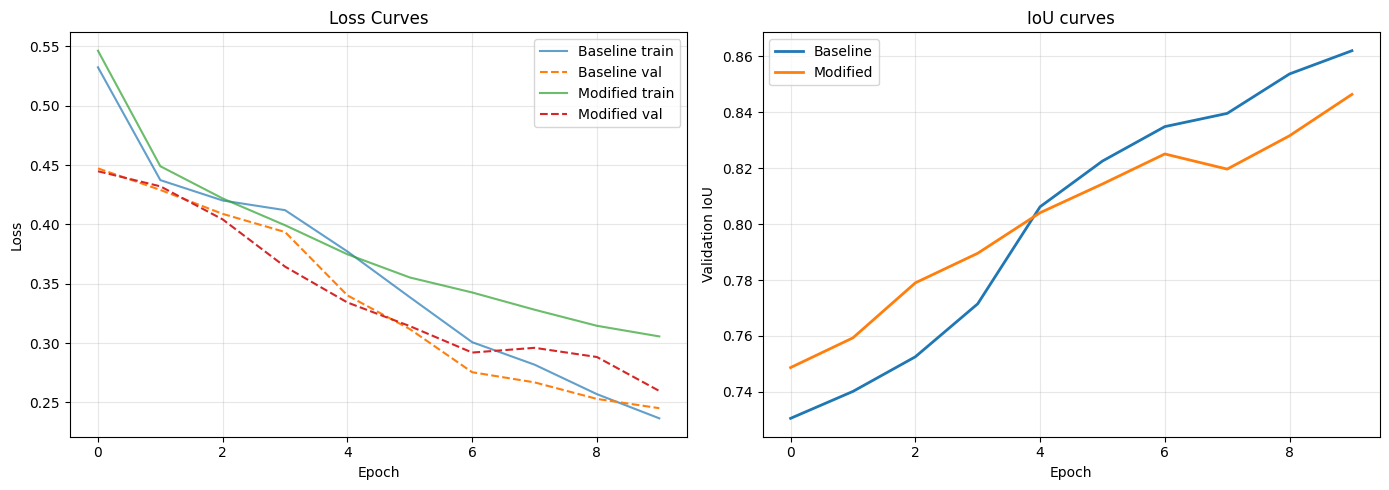

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(base_train_losses, label='Baseline train', alpha=0.7)
axes[0].plot(base_val_losses, label='Baseline val', linestyle='--')
axes[0].plot(modified_train_losses, label='Modified train', alpha=0.7)
axes[0].plot(modified_val_losses, label='Modified val', linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(base_val_ious, label='Baseline', linewidth=2)
axes[1].plot(modified_val_ious, label='Modified', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation IoU')
axes[1].set_title('IoU curves')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##Пробуем уменьшить dropout

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 92/92 [00:12<00:00,  7.30it/s]


Epoch 1 / 10, Train Loss: 0.4769, Val Loss: 0.3873, Val IoU: 0.7826, Val F1-score: 0.8712


100%|██████████| 92/92 [00:12<00:00,  7.34it/s]


Epoch 2 / 10, Train Loss: 0.3653, Val Loss: 0.3218, Val IoU: 0.8184, Val F1-score: 0.8936


100%|██████████| 92/92 [00:12<00:00,  7.25it/s]


...

Epoch 8 / 10, Train Loss: 0.2265, Val Loss: 0.2107, Val IoU: 0.8680, Val F1-score: 0.9250


100%|██████████| 92/92 [00:12<00:00,  7.33it/s]


Epoch 9 / 10, Train Loss: 0.2137, Val Loss: 0.2055, Val IoU: 0.8746, Val F1-score: 0.9287


100%|██████████| 92/92 [00:15<00:00,  5.79it/s]


Epoch 10 / 10, Train Loss: 0.2059, Val Loss: 0.2133, Val IoU: 0.8680, Val F1-score: 0.9248


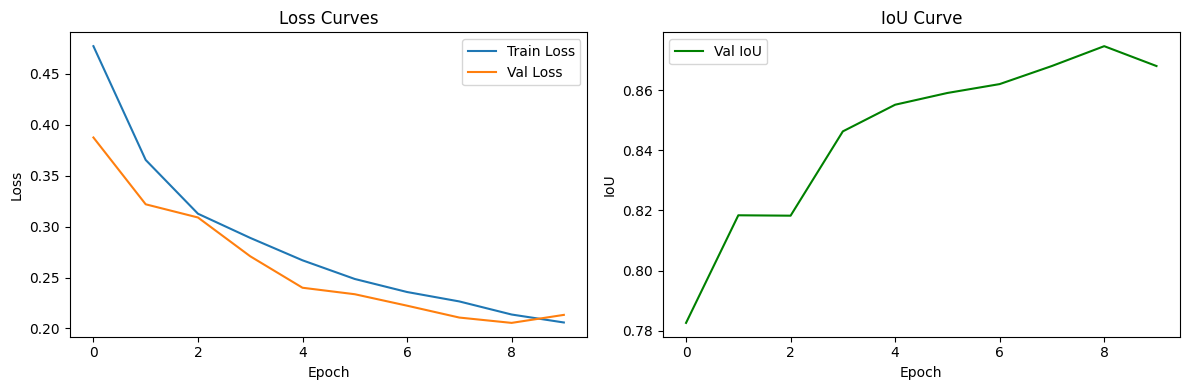

100%|██████████| 459/459 [01:12<00:00,  6.32it/s]

Test Loss: 0.2027, Test IoU: 0.8748, Test F1-score: 0.9289

Modified results:
IoU: 0.8748
F1: 0.9289


In [12]:
config = Config()
config.learning_rate = 0.0001
config.batch_size = 8
config.epochs = 10

trainer_modified = Trainer(config)
trainer_modified.model = UNetModified(dropout_rate=0.1).to(config.device)
trainer_modified.optimizer = optim.Adam(trainer_modified.model.parameters(), lr=config.learning_rate)

trainer_modified.run()

modified_iou = trainer_modified.test_iou
modified_f1 = trainer_modified.test_f1
modified_train_losses = trainer_modified.train_losses
modified_val_losses = trainer_modified.val_losses
modified_val_ious = trainer_modified.val_ious

print(f"\nModified results:")
print(f"IoU: {modified_iou:.4f}")
print(f"F1: {modified_f1:.4f}")

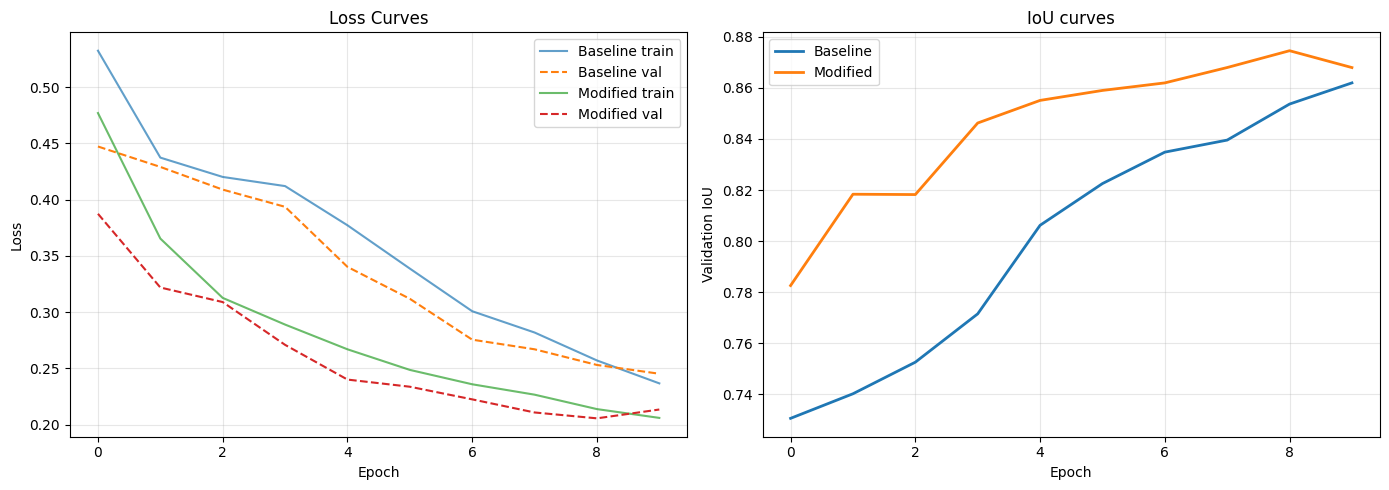

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(base_train_losses, label='Baseline train', alpha=0.7)
axes[0].plot(base_val_losses, label='Baseline val', linestyle='--')
axes[0].plot(modified_train_losses, label='Modified train', alpha=0.7)
axes[0].plot(modified_val_losses, label='Modified val', linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(base_val_ious, label='Baseline', linewidth=2)
axes[1].plot(modified_val_ious, label='Modified', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation IoU')
axes[1].set_title('IoU curves')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##Здесь разница очевидна: IoU модифицированной модели с dropout = 0.1 больше, loss значительно меньше.

###Выводы:
Сильная регуляризация (dropout = 0.3) оказалась избыточной, при dropout = 0.1 модель показала лучшие результаты. Такая комбинация с BatchNorm неплохо улучшила сходимость.

Разрыв между train loss и val loss у бейзлайна оказался небольшим (хорошо видно на графиках), модель хорошо обобщается на новые данные без переобучения. С dropout = 0.3 более высокий лосс и разрыв, модификации оказались не совсем подходящими.